# Demo EfficientLoFTR on a single pair of images

This notebook shows how to use the eloftr matcher with different model type and numerical precision on the pretrained weights.

In [1]:
import os
os.chdir("..")
from copy import deepcopy

import torch
import cv2
import numpy as np
import matplotlib.cm as cm
from src.utils.plotting import make_matching_figure

## Outdoor Example

We recommend using our pre-trained model for input in outdoor environments because our model has only been trained on MegaDepth, and there exists a domain gap between indoor and outdoor data.

In [3]:
from src.loftr import LoFTR, full_default_cfg, opt_default_cfg, reparameter

# You can choose model type in ['full', 'opt']
model_type = 'full' # 'full' for best quality, 'opt' for best efficiency

# You can choose numerical precision in ['fp32', 'mp', 'fp16']. 'fp16' for best efficiency
precision = 'fp32' # Enjoy near-lossless precision with Mixed Precision (MP) / FP16 computation if you have a modern GPU (recommended NVIDIA architecture >= SM_70).

# You can also change the default values like thr. and npe (based on input image size)

if model_type == 'full':
    _default_cfg = deepcopy(full_default_cfg)
elif model_type == 'opt':
    _default_cfg = deepcopy(opt_default_cfg)
    
if precision == 'mp':
    _default_cfg['mp'] = True
elif precision == 'fp16':
    _default_cfg['half'] = True
    
print(_default_cfg)
matcher = LoFTR(config=_default_cfg)

matcher.load_state_dict(torch.load("weights/eloftr_outdoor.ckpt", weights_only=False)['state_dict'])
matcher = reparameter(matcher) # no reparameterization will lead to low performance

if precision == 'fp16':
    matcher = matcher.half()

matcher = matcher.eval().cuda()

{'backbone_type': 'RepVGG', 'align_corner': False, 'resolution': (8, 1), 'fine_window_size': 8, 'mp': False, 'replace_nan': True, 'half': False, 'backbone': {'block_dims': [64, 128, 256]}, 'coarse': {'d_model': 256, 'd_ffn': 256, 'nhead': 8, 'layer_names': ['self', 'cross', 'self', 'cross', 'self', 'cross', 'self', 'cross'], 'agg_size0': 4, 'agg_size1': 4, 'no_flash': False, 'rope': True, 'npe': [832, 832, 832, 832]}, 'match_coarse': {'thr': 0.2, 'border_rm': 2, 'dsmax_temperature': 0.1, 'skip_softmax': False, 'fp16matmul': False, 'train_coarse_percent': 0.2, 'train_pad_num_gt_min': 200}, 'match_fine': {'local_regress_temperature': 10.0, 'local_regress_slicedim': 8}}


In [4]:
# Load example images
img0_pth = "assets/phototourism_sample_images/united_states_capitol_26757027_6717084061.jpg"
img1_pth = "assets/phototourism_sample_images/united_states_capitol_98169888_3347710852.jpg"
img0_raw = cv2.imread(img0_pth, cv2.IMREAD_GRAYSCALE)
img1_raw = cv2.imread(img1_pth, cv2.IMREAD_GRAYSCALE)
img0_raw = cv2.resize(img0_raw, (img0_raw.shape[1]//32*32, img0_raw.shape[0]//32*32))  # input size shuold be divisible by 32
img1_raw = cv2.resize(img1_raw, (img1_raw.shape[1]//32*32, img1_raw.shape[0]//32*32))

if precision == 'fp16':
    img0 = torch.from_numpy(img0_raw)[None][None].half().cuda() / 255.
    img1 = torch.from_numpy(img1_raw)[None][None].half().cuda() / 255.
else:
    img0 = torch.from_numpy(img0_raw)[None][None].cuda() / 255.
    img1 = torch.from_numpy(img1_raw)[None][None].cuda() / 255.
batch = {'image0': img0, 'image1': img1}

# Inference with EfficientLoFTR and get prediction
with torch.no_grad():
    if precision == 'mp':
        with torch.autocast(enabled=True, device_type='cuda'):
            matcher(batch)
    else:
        matcher(batch)
    mkpts0 = batch['mkpts0_f'].cpu().numpy()
    mkpts1 = batch['mkpts1_f'].cpu().numpy()
    mconf = batch['mconf'].cpu().numpy()

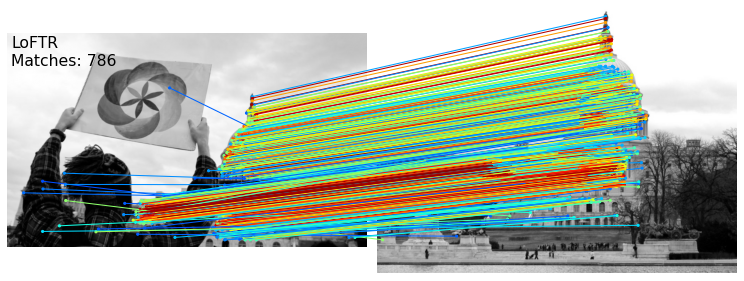

In [ ]:
# Draw
if model_type == 'opt':
    print(mconf.max())
    mconf = (mconf - min(20.0, mconf.min())) / (max(30.0, mconf.max()) - min(20.0, mconf.min()))

color = cm.jet(mconf)
text = [
    # 'LoFTR',
    'Matches: {}'.format(len(mkpts0)),
]
fig = make_matching_figure(img0_raw, img1_raw, mkpts0, mkpts1, color, text=text)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import cv2

def make_matching_figure(
        img0, img1, mkpts0, mkpts1, color,
        kpts0=None, kpts1=None, text=[], dpi=75, path=None):
    # draw image pair
    assert mkpts0.shape[0] == mkpts1.shape[0], f'mkpts0: {mkpts0.shape[0]} v.s. mkpts1: {mkpts1.shape[0]}'
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=dpi)
    axes[0].imshow(img0, cmap='gray')
    axes[1].imshow(img1, cmap='gray')
    for i in range(2):   # clear all frames
        axes[i].get_yaxis().set_ticks([])
        axes[i].get_xaxis().set_ticks([])
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    plt.tight_layout(pad=1)
    
    if kpts0 is not None:
        assert kpts1 is not None
        axes[0].scatter(kpts0[:, 0], kpts0[:, 1], c='w', s=2)
        axes[1].scatter(kpts1[:, 0], kpts1[:, 1], c='w', s=2)

    # draw matches
    if mkpts0.shape[0] != 0 and mkpts1.shape[0] != 0:
        fig.canvas.draw()
        transFigure = fig.transFigure.inverted()
        fkpts0 = transFigure.transform(axes[0].transData.transform(mkpts0))
        fkpts1 = transFigure.transform(axes[1].transData.transform(mkpts1))
        fig.lines = [matplotlib.lines.Line2D((fkpts0[i, 0], fkpts1[i, 0]),
                                            (fkpts0[i, 1], fkpts1[i, 1]),
                                            transform=fig.transFigure, c=color[i], linewidth=1)
                                        for i in range(len(mkpts0))]
        
        axes[0].scatter(mkpts0[:, 0], mkpts0[:, 1], c=color, s=4)
        axes[1].scatter(mkpts1[:, 0], mkpts1[:, 1], c=color, s=4)

    # put txts
    txt_color = 'k' if img0[:100, :200].mean() > 200 else 'w'
    fig.text(
        0.01, 0.99, '\n'.join(text), transform=fig.axes[0].transAxes,
        fontsize=15, va='top', ha='left', color=txt_color)

    # save or return figure
    if path:
        plt.savefig(str(path), bbox_inches='tight', pad_inches=0)
        plt.close()
    
    return fig

In [19]:
import os
def demo_pair(img0_pth, img1_pth, thr=0.6, size=640):
    matcher.coarse_matching.thr = thr
    img0_bgr = cv2.imread(img0_pth)
    img1_bgr = cv2.imread(img1_pth)
    img0_bgr = cv2.resize(img0_bgr, (size, size))  # input size shuold be divisible by 32
    img1_bgr = cv2.resize(img1_bgr, (size, size))


    img0_raw = cv2.cvtColor(img0_bgr, cv2.COLOR_BGR2GRAY)
    img1_raw = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)

    img0_rgb = img0_bgr[:, :, ::-1]
    img1_rgb = img1_bgr[:, :, ::-1]

    # img0_raw = cv2.resize(img0_raw, (img0_raw.shape[1]//32*32, img0_raw.shape[0]//32*32))  # input size shuold be divisible by 32
    # img1_raw = cv2.resize(img1_raw, (img1_raw.shape[1]//32*32, img1_raw.shape[0]//32*32))

    if precision == 'fp16':
        img0 = torch.from_numpy(img0_raw)[None][None].half().cuda() / 255.
        img1 = torch.from_numpy(img1_raw)[None][None].half().cuda() / 255.
    else:
        img0 = torch.from_numpy(img0_raw)[None][None].cuda() / 255.
        img1 = torch.from_numpy(img1_raw)[None][None].cuda() / 255.
    batch = {'image0': img0, 'image1': img1}

    # Inference with EfficientLoFTR and get prediction
    with torch.no_grad():
        if precision == 'mp':
            with torch.autocast(enabled=True, device_type='cuda'):
                matcher(batch)
        else:
            matcher(batch)
        mkpts0 = batch['mkpts0_f'].cpu().numpy()
        mkpts1 = batch['mkpts1_f'].cpu().numpy()
        mconf = batch['mconf'].cpu().numpy()

    color = ['g']*len(mconf)
    text = [
        # 'LoFTR',
        'Matches: {}'.format(len(mkpts0)),
    ]

    out_file = 'eloftr2_' + os.path.basename(img0_pth)
    out_file = os.path.join('/home/rwang/data/projects/papers/CoReMatch/images/qc2', out_file)


    fig = make_matching_figure(img0_rgb, img1_rgb, mkpts0, mkpts1, color, text=text, path=out_file)

    return fig



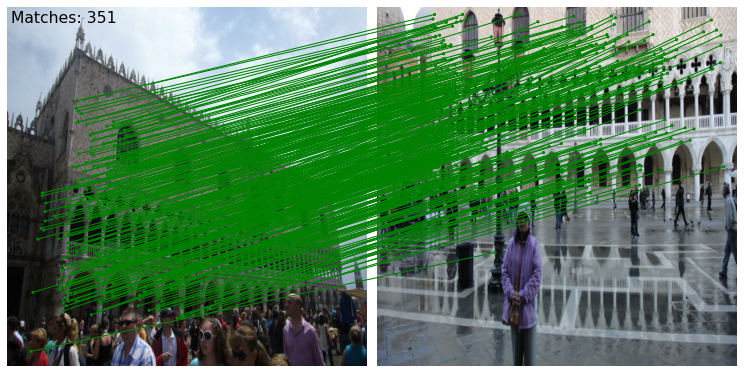

In [21]:
img0_pth='assets/phototourism_sample_images/piazza_san_marco_06795901_3725050516.jpg'
img1_pth = 'assets/phototourism_sample_images/piazza_san_marco_15148634_5228701572.jpg'
demo_pair(img0_pth, img1_pth, thr=0.4)

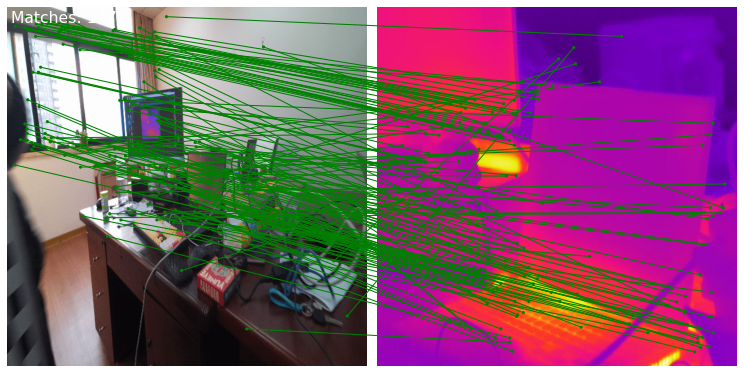

In [24]:
img0_pth='assets/eoir/e2_rgb_2.jpg'
img1_pth = 'assets/eoir/e2_thermal_1.jpg'
demo_pair(img0_pth, img1_pth, thr=0.1)

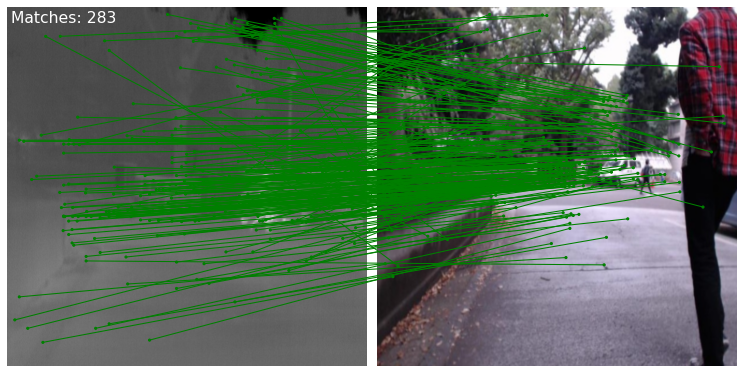

In [25]:
img0_pth='assets/eoir/e3_vis_thermal_ground_1.jpg'
img1_pth = 'assets/eoir/e3_vis_thermal_ground_2.jpg'
demo_pair(img0_pth, img1_pth, thr=0.1)

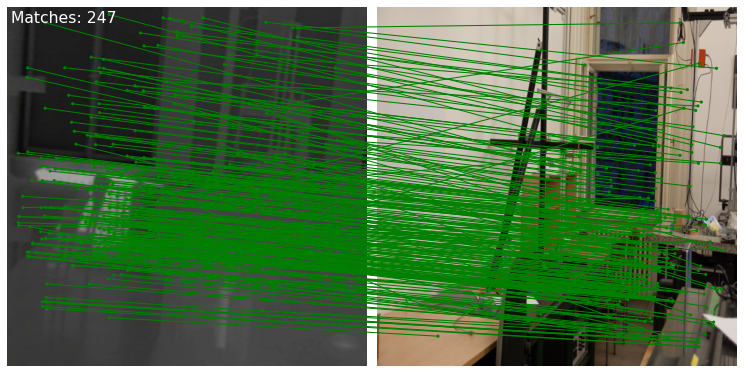

In [26]:
img0_pth='assets/eoir/e5_01.jpg'
img1_pth = 'assets/eoir/e5_02.jpg'

# out_file = None
demo_pair(img0_pth, img1_pth, thr=0.1)

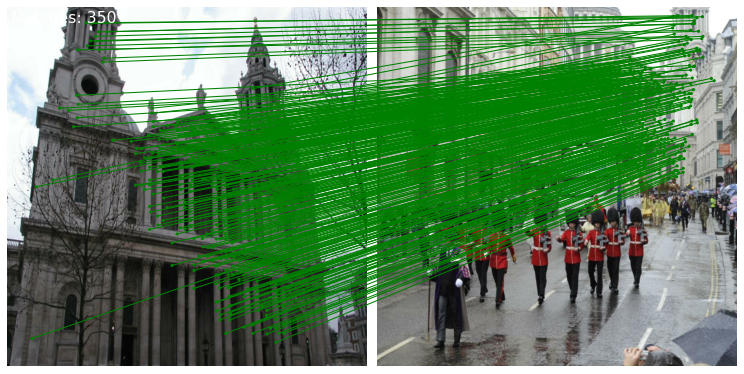

In [27]:
img0_pth='/home/rwang/source/eloftr/assets/phototourism_sample_images/st_pauls_cathedral_30776973_2635313996.jpg'
img1_pth = '/home/rwang/source/eloftr/assets/phototourism_sample_images/st_pauls_cathedral_37347628_10902811376.jpg'
demo_pair(img0_pth, img1_pth, thr=0.5)

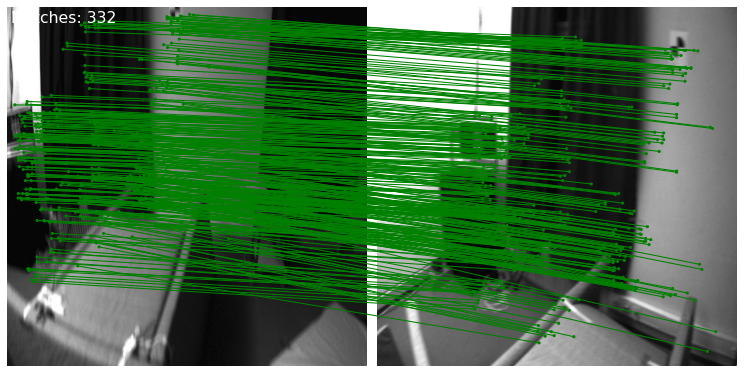

In [28]:
img0_pth='assets/blur_a_1527045014417.jpg'
img1_pth = 'assets/blur_b.jpg'
demo_pair(img0_pth, img1_pth, thr=0.5)

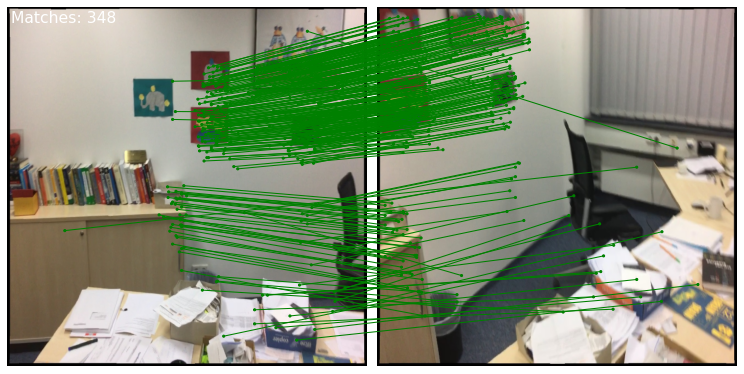

In [29]:
img0_pth='assets/scannet_sample_images/scene0758_00_165.jpg'
img1_pth = 'assets/scannet_sample_images/scene0758_00_510.jpg'
demo_pair(img0_pth, img1_pth, thr=0.5)

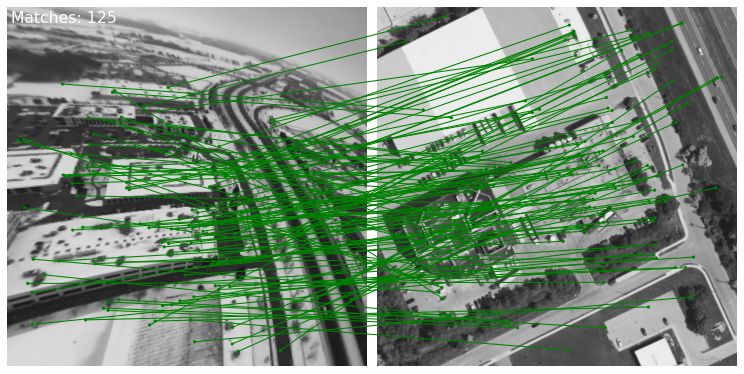

In [32]:
img0_pth='assets/00085_18_warped.png'
img1_pth = 'assets/00085_18_img1.png'
demo_pair(img0_pth, img1_pth, thr=0.3)